In [1]:
import sys
from pathlib import Path
# Add notebook directory to path to enable imports
this_dir = Path().absolute()
if str(this_dir) not in sys.path:
	sys.path.insert(0, str(this_dir))
from astropy.io import fits
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import matplotlib.pyplot as plt
import healpy as hp
import os
from ligo.skymap.io.fits import read_sky_map
from ligo.skymap.moc import uniq2nest, uniq2pixarea
from model_v1 import GWOpticalFusionModel
from tqdm import tqdm
import h5py
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")


/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def sample_moc_skymap(map_file):
    """
    Convert UNIQ to sky coordinates and calculte pixel areas.
    Note: Do not include DISTNORM in the output. For inf values in DISTMU, relace with distmean and diststd from metadata.
    """
    
    # read moc skymap and metadata
    moc_map = read_sky_map(map_file, moc=True, distances=True)
    _, meta = read_sky_map(map_file, nest=True)

    # extract distance meta info
    dist_mean = meta.get('distmean', None)
    dist_std = meta.get('diststd', None)

    uniq = moc_map['UNIQ']
    probdensity = moc_map['PROBDENSITY']
    distmu = moc_map['DISTMU']
    distsigma = moc_map['DISTSIGMA']
    # distnorm = moc_map['DISTNORM']  # not used

    # 1) UNIQ -> order, ipix, nside
    order, ipix = uniq2nest(uniq)

    # 2) caculate pixel area
    dA = uniq2pixarea(uniq)
    # 3) calculate pixel probability
    dP = probdensity * dA
    # 4) calculate theta, phi
    xs  = np.zeros_like(ipix, dtype=np.float32)
    ys = np.zeros_like(ipix, dtype=np.float32)
    zs = np.zeros_like(ipix, dtype=np.float32)
    for k in np.unique(order):
        m = (order == k)
        this_ipix  = ipix[m]
        this_nside = 2 ** k
        theta, phi = hp.pix2ang(this_nside, this_ipix, nest=True)
        # ras[m]  = np.degrees(phi)
        # decs[m] = 90.0 - np.degrees(theta)
        xs[m] = np.cos(theta) * np.cos(phi)   # dec,[0, pi]
        ys[m] = np.cos(theta) * np.sin(phi)   # ra,[0, 2pi]
        zs[m] = np.sin(theta)
    
    # 5) return torch tensors
    gw_mocmap = torch.tensor(np.vstack([xs, ys, zs, dA, 100 * dP, distmu, distsigma]), dtype=torch.float32)   # [7, N_pixels], no distnorm

    # 6) process unnormal distance values
    inf_dist_mu = torch.where(torch.isinf(gw_mocmap[5]))[0]
    gw_mocmap[5, inf_dist_mu] = dist_mean  # set inf to mean value
    gw_mocmap[6, inf_dist_mu] = dist_std   # set inf to std value
    gw_mocmap[5,:] = gw_mocmap[5,:] / 1000.0  # scale down
    gw_mocmap[6,:] = gw_mocmap[6,:] / 1000.0 # scale down

    return gw_mocmap  # [7, N_pixels]

BAND_MAP = {'LSST-u': 0, 'LSST-g': 1, 'LSST-r': 2, 'LSST-i': 3, 'LSST-z': 4, 'LSST-Y': 5}
NUM_BANDS = 6
MAX_LC_LENGTH = 200  # Maximum length of light curves all band
def parse_snana_fits(fits_dir, event_name):
    """
    Parses {event_id}_HEAD.fits and {event_id}_PHOT.fits.
    Extracts multiple light curve realizations for a single GW event.
    
    Args:
        event_id: String ID of the event.
        sim_dir: Directory containing FITS files.
        
    Returns:
        List of tuples: [(values, masks, times), ...]
        Returns empty list if files are missing.
    """

    head_path = os.path.join(fits_dir, f"{event_name}",f"{event_name}_HEAD.FITS")
    phot_path = os.path.join(fits_dir, f"{event_name}",f"{event_name}_PHOT.FITS")

    if not os.path.exists(head_path) or not os.path.exists(phot_path):
        print(f"Warning: FITS files not found for {event_name}")
        return []

    try:
        # open readme file and get MJD explode value
        with open(os.path.join(fits_dir, f"{event_name}",f"{event_name}.README")) as f:
            readme_lines = f.readlines()
            mjd_explode = readme_lines[27].split(":")[1].split()[0]
            mjd_explode = float(mjd_explode)
            print(f"Event {event_name}: MJD explode = {mjd_explode}")
        # Open FITS files
        with fits.open(head_path) as hdul_head, fits.open(phot_path) as hdul_phot:
            # Usually data is in extension 1
            data_head = hdul_head[1].data
            data_phot = hdul_phot[1].data
            
            # Use columns directly (Astropy FITS columns are case-insensitive usually)
            # HEAD columns
            ptrobs_min = data_head['PTROBS_MIN']
            ptrobs_max = data_head['PTROBS_MAX']
            
            # PHOT columns
            mjd_all = data_phot['MJD']
            flux_all = data_phot['FLUXCAL']
            fluxerr_all = data_phot['FLUXCALERR'] # Optional usage
            flt_all = data_phot['BAND'] # Filters

            extracted_lcs = []
            
            # Iterate over each realization in HEAD
            for i in range(len(data_head)):
                # SNANA uses 1-based indexing for pointers, Python uses 0-based
                # Start index: value - 1
                # End index: value (exclusive in python slicing)
                start_idx = ptrobs_min[i] - 1
                end_idx = ptrobs_max[i]

                # get coordinates
                ra = data_head['RA'][i]
                dec = data_head['DEC'][i]
                coordinates = np.array([ra, dec], dtype=np.float32)
                
                # Slicing the PHOT data
                lc_mjd = mjd_all[start_idx : end_idx]
                lc_flux = flux_all[start_idx : end_idx]
                lc_fluxerr = fluxerr_all[start_idx : end_idx]
                lc_flt = flt_all[start_idx : end_idx]

                # Normalization
                std = np.std(lc_flux)
                mean = np.mean(lc_flux)
                lc_flux = (lc_flux - mean) / (std + 1e-8)
                lc_fluxerr = lc_fluxerr / (std + 1e-8)
                
                # --- Format Conversion (to Tensor-ready numpy) ---
                val_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)    # Values matrix (flux)
                err_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)    # Errors matrix (flux errors)
                mask_mat = np.zeros((MAX_LC_LENGTH, NUM_BANDS), dtype=np.float32)
                time_vec = np.zeros((MAX_LC_LENGTH,), dtype=np.float32)
                
                # 1. Time Normalization (Relative to BNS merger time)
                if len(lc_mjd) > 0:
                    rel_times = (lc_mjd - mjd_explode) / 100  # Scale down to manageable range[-0.3, 0.6]
                else:
                    continue # Skip empty light curves

                # 2. Fill Matrices
                # Truncate if longer than MAX_LC_LENGTH
                seq_len = min(len(lc_mjd), MAX_LC_LENGTH)
                if len(lc_mjd) > MAX_LC_LENGTH:
                    print(f"Warning: Light curve for event {event_name} exceeds MAX_LC_LENGTH. Truncating.")
                    # Keep the MAX_LC_LENGTH points with smallest absolute rel_times
                    sorted_indices = np.argsort(np.abs(rel_times))[:MAX_LC_LENGTH]
                    sorted_indices = np.sort(sorted_indices)  # Sort back to chronological order
                    lc_mjd = lc_mjd[sorted_indices]
                    lc_flux = lc_flux[sorted_indices]
                    lc_fluxerr = lc_fluxerr[sorted_indices]
                    lc_flt = lc_flt[sorted_indices]
                    rel_times = rel_times[sorted_indices]
                
                for t in range(seq_len):
                    band_char = lc_flt[t].strip() # Remove whitespace
                    if band_char in BAND_MAP:
                        b_idx = BAND_MAP[band_char]
                        
                        val_mat[t, b_idx] = lc_flux[t]
                        err_mat[t, b_idx] = lc_fluxerr[t]
                        mask_mat[t, b_idx] = 1.0
                        time_vec[t] = rel_times[t]
                
                extracted_lcs.append((val_mat, err_mat, mask_mat, time_vec, coordinates))
                
            return extracted_lcs

    except Exception as e:
        print(f"Error processing FITS for {event_name}: {e}")
        return []

# get data of GW170817A/AT2017gfo

In [3]:
gw_params = h5py.File('/fred/oz016/bgao_kn/data/GW170817A/GW170817_GWTC-1.hdf5','r')
highspin_postpiror = gw_params['/IMRPhenomPv2NRT_highSpin_posterior'][:]
lowspin_postpiror = gw_params['/IMRPhenomPv2NRT_lowSpin_posterior'][:]

In [4]:
spin1 = lowspin_postpiror['spin1']
spin2 = lowspin_postpiror['spin2']
mass1_detector = lowspin_postpiror['m1_detector_frame_Msun']
mass2_detector = lowspin_postpiror['m2_detector_frame_Msun']
distances = lowspin_postpiror['luminosity_distance_Mpc']
cos_inclination = lowspin_postpiror['costheta_jn']
inclination = np.arccos(cos_inclination)

redshift = np.array([z_at_value(cosmo.luminosity_distance, d * u.Mpc) for d in distances])
print(f"Redshift: {np.mean(redshift)}")
print(f"Spin1z: {np.mean(spin1)}, Spin2z: {np.mean(spin2)}")
print(f"Mass1 detector frame: {np.mean(mass1_detector)}, Mass2 detector frame: {np.mean(mass2_detector)}")
print(f"Luminosity distance (Mpc): {np.mean(distances)}")
print(f"Inclination (radians): {np.arccos(np.mean(cos_inclination))}")

Redshift: 0.008616218989159896
Spin1z: 0.023265200435027916, Spin2z: 0.022787912334285128
Mass1 detector frame: 1.4900663499588278, Mass2 detector frame: 1.2755048307759151
Luminosity distance (Mpc): 38.43694858086378
Inclination (radians): 2.491242346762126


In [5]:
_, meta = read_sky_map("/fred/oz016/bgao_kn/data/GW170817A/bayestar_no_virgo.fits", nest=True)
dist_mean = meta.get('distmean', None)
dist_std = meta.get('diststd', None)
print(f"Distance mean from skymap meta: {dist_mean}, std: {dist_std}")

Distance mean from skymap meta: 34.14916633836531, std: 9.33511946724046


In [6]:
pos_gw_scalar = torch.tensor([np.mean(mass1_detector), 
                           np.mean(mass2_detector), 
                           np.mean(spin1), np.mean(spin2), 
                           np.mean(inclination), 
                           dist_mean/100, dist_std/100],dtype=torch.float32) #['mass1', 'mass2', 'spin1z', 'spin2z', 'inclination', 'distmean', 'diststd']
print(f"GW scalars: {pos_gw_scalar}")

GW scalars: tensor([1.4901, 1.2755, 0.0233, 0.0228, 2.5451, 0.3415, 0.0934])


In [7]:
mocmap = read_sky_map("/fred/oz016/bgao_kn/data/GW170817A/bayestar_no_virgo.fits", moc=True, distances=True)
mocmap[:5]

UNIQ,PROBDENSITY,DISTMU,DISTSIGMA,DISTNORM
,1 / sr,Mpc,Mpc,1 / Mpc2
int64,float64,float64,float64,float64
1034,2.4966020841978613e-37,19.19563987673948,1.7826137349205506,0.0026907014325134996
1035,1.0389497033714659e-36,2.2013325633997183,11.044852927444497,0.012056213204615196
1056,8.688359467874061e-41,18.441244422539647,0.9845445958195134,0.002932131501075268
1057,1.0490244601571994e-40,19.65168241161706,1.2067426874393585,0.00257968086313108
1058,1.5735598849655988e-42,17.161938079029873,0.9073053161738321,0.003385752437777578


In [8]:
pos_gw_moc = sample_moc_skymap("/fred/oz016/bgao_kn/data/GW170817A/bayestar_no_virgo.fits")
print(f"GW MOC map shape: {pos_gw_moc.shape}")

GW MOC map shape: torch.Size([7, 19200])


## Get optical data

In [9]:
inclination = np.arccos(np.mean(cos_inclination))
print(f"Inclination (rad): {inclination}")
if inclination > np.pi / 2:
    theta = np.pi - inclination
else:
    theta = inclination
print(f"Viewing angle theta (rad): {theta}")
cos_theta = np.cos(theta)
print(f"Cosine viewing angle cos(theta): {cos_theta}")

Inclination (rad): 2.491242346762126
Viewing angle theta (rad): 0.6503503068276673
Cosine viewing angle cos(theta): 0.7958717487777902


In [10]:
pos_lc = parse_snana_fits(fits_dir="/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM", event_name="LSST_KN_GW170817_0.1")
pos_val_obs, pos_err_obs, pos_mask_obs, pos_time_obs, pos_coords = pos_lc[0]
pos_opt_v = torch.tensor(pos_val_obs, dtype=torch.float32).unsqueeze(0)  # add batch dimension
pos_opt_err = torch.tensor(pos_err_obs, dtype=torch.float32).unsqueeze(0)  # add batch dimension
pos_opt_mask = torch.tensor(pos_mask_obs, dtype=torch.float32).unsqueeze(0)  # add batch dimension
pos_opt_t = torch.tensor(pos_time_obs, dtype=torch.float32).unsqueeze(0)  # add batch dimension
pos_opt_coords = torch.tensor(pos_coords, dtype=torch.float32).unsqueeze(0)  # add batch dimension
print(f"Extracted light curve values shape: {pos_opt_v.shape}")

Event LSST_KN_GW170817_0.1: MJD explode = 63000.0
Extracted light curve values shape: torch.Size([1, 200, 6])


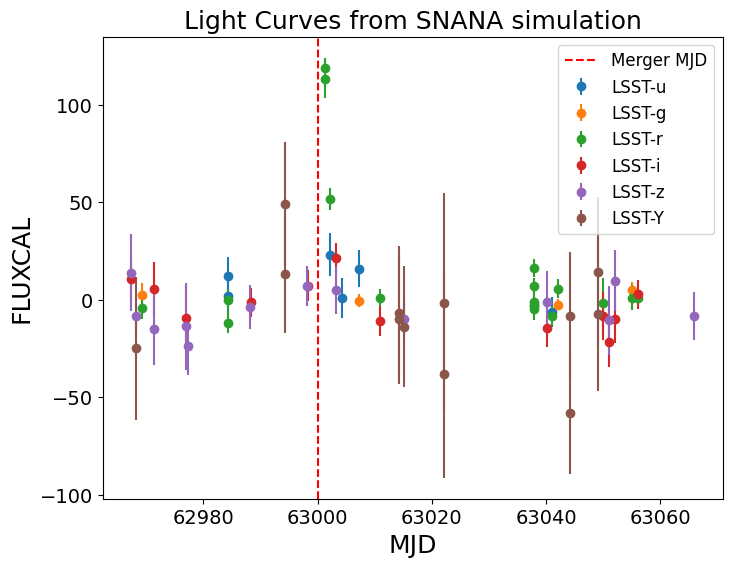

In [11]:
# load data for test
import matplotlib.pyplot as plt
# 打开PHOT.fits文件
neg_fits="/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN_BNS_16/LSST_KN_BNS_16_PHOT.FITS"
pos_fits="/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM/LSST_KN_GW170817_0.1/LSST_KN_GW170817_0.1_PHOT.FITS"
phot_hdul = fits.open(pos_fits)
phot_data = phot_hdul[1].data

mjd_explode = 63000
# plot light curve for verification
bands = ['LSST-u','LSST-g','LSST-r','LSST-i','LSST-z','LSST-Y']
plt.figure(figsize=(8,6))
plt.axvline(x=mjd_explode, color='r', linestyle='--', label="Merger MJD")
source_data = phot_data[:77]  # FITS索引通常从1开始
# source_data = source_data[np.logical_and(source_data['MJD']>=mjd_explode[0]-5, source_data['MJD']<=mjd_explode[0]+15)]
mjd = source_data['MJD']
flux = source_data['FLUXCAL']
fluxerr = source_data['FLUXCALERR']
# mag, magerr = convert_fluxcal_to_mag(flux=flux.copy(), err=fluxerr)
for band in bands:
    band_mask = source_data['BAND'] == band
    # plt.errorbar(mjd[band_mask], mag[band_mask], yerr=magerr[band_mask], fmt='o', label=band)
    plt.errorbar(mjd[band_mask], flux[band_mask], yerr=fluxerr[band_mask], fmt='o', label=band)
    # plt.errorbar(mjd, flux, yerr=err, fmt='o', label=f'Source {i+1}')
    plt.xlabel('MJD', fontsize=18)
    plt.xticks(fontsize=14)
    plt.ylabel('FLUXCAL', fontsize=18)
    plt.yticks(fontsize=14)
    plt.title('Light Curves from SNANA simulation', fontsize=18)
    plt.legend(fontsize=12)

## generate some negative sample pairs

In [12]:
neg_mass1, neg_mass2 = 1.8, 1.0
neg_spin1z, neg_spin2z = 0.5, 0.0
neg_inclination = 1.0
neg_distmean, neg_diststd = 500.0, 100.0 
neg_gw_scalars_dicts = {
    'mass1_detector': neg_mass1,
    'mass2_detector': neg_mass2,
    'spin1z': neg_spin1z,
    'spin2z': neg_spin2z,
    'inclination': neg_inclination,
    'distmean': neg_distmean / 1000,
    'diststd': neg_diststd / 1000
}
fully_neg_gw_scalar = torch.tensor(
    [neg_mass1, neg_mass2, neg_spin1z, neg_spin2z, neg_inclination, neg_distmean / 1000, neg_diststd / 1000],
    dtype=torch.float32
)


In [13]:
neg_gw_moc = sample_moc_skymap("/fred/oz016/bgao_kn/data/bns_skymap/26.fits")
print(f"Negative GW MOC map shape: {neg_gw_moc.shape}")


Negative GW MOC map shape: torch.Size([7, 19200])


In [14]:
neg_lc = parse_snana_fits(fits_dir="/fred/oz016/bgao_kn/SNANA/SNDATA_ROOT/SIM", event_name="LSST_KN_BNS_16")
neg_val_obs, neg_err_obs, neg_mask_obs, neg_time_obs, neg_coords = neg_lc[0]
neg_opt_v = torch.tensor(neg_val_obs, dtype=torch.float32).unsqueeze(0)  # add batch dimension
neg_opt_err = torch.tensor(neg_err_obs, dtype=torch.float32).unsqueeze(0)  # add batch dimension
neg_opt_mask = torch.tensor(neg_mask_obs, dtype=torch.float32).unsqueeze(0)  # add batch dimension
neg_opt_t = torch.tensor(neg_time_obs, dtype=torch.float32).unsqueeze(0)  # add batch dimension
neg_opt_coords = torch.tensor(neg_coords, dtype=torch.float32).unsqueeze(0)  # add batch dimension


Event LSST_KN_BNS_16: MJD explode = 63197.6935


In [15]:
cases = []
cases.append({
    "name": "pos_all",
    "gw_scalar": pos_gw_scalar,
    "gw_moc": pos_gw_moc,
    "opt": "pos"
})

for i, (key, value) in enumerate(neg_gw_scalars_dicts.items()):
    gw_scalar = pos_gw_scalar.clone()
    gw_scalar[i] = value
    cases.append({
        "name": f"change_{key}",
        "gw_scalar": gw_scalar,
        "gw_moc": pos_gw_moc,
        "opt": "pos"
    })

cases.append({
    "name": "neg_skymap_only",
    "gw_scalar": pos_gw_scalar,
    "gw_moc": neg_gw_moc,
    "opt": "pos"
})

cases.append({
    "name": "neg_opt_only",
    "gw_scalar": pos_gw_scalar,
    "gw_moc": pos_gw_moc,
    "opt": "neg"
})

cases.append({
    "name": "neg_all",
    "gw_scalar": fully_neg_gw_scalar,
    "gw_moc": neg_gw_moc,
    "opt": "neg"
})

case_names = [c["name"] for c in cases]

gw_scalars = torch.stack([c["gw_scalar"] for c in cases], dim=0)
gw_moc = torch.stack([c["gw_moc"] for c in cases], dim=0)

def _opt_for_case(case):
    if case["opt"] == "pos":
        return pos_opt_v, pos_opt_err, pos_opt_mask, pos_opt_t, pos_opt_coords
    return neg_opt_v, neg_opt_err, neg_opt_mask, neg_opt_t, neg_opt_coords

opt_v = torch.cat([_opt_for_case(c)[0] for c in cases], dim=0)
opt_err = torch.cat([_opt_for_case(c)[1] for c in cases], dim=0)
opt_mask = torch.cat([_opt_for_case(c)[2] for c in cases], dim=0)
opt_t = torch.cat([_opt_for_case(c)[3] for c in cases], dim=0)
opt_coords = torch.cat([_opt_for_case(c)[4] for c in cases], dim=0)

print(f"Cases: {case_names}")
print(f"GW scalars shape: {gw_scalars.shape}")
print(f"GW MOC map shape: {gw_moc.shape}")
print(f"Optical data shape after repeat: {opt_v.shape}")


Cases: ['pos_all', 'change_mass1_detector', 'change_mass2_detector', 'change_spin1z', 'change_spin2z', 'change_inclination', 'change_distmean', 'change_diststd', 'neg_skymap_only', 'neg_opt_only', 'neg_all']
GW scalars shape: torch.Size([11, 7])
GW MOC map shape: torch.Size([11, 7, 19200])
Optical data shape after repeat: torch.Size([11, 200, 6])


Data explanation:
- pos,
- neg-m1,
- meg-m2,
- neg-s1,
- neg-s2,
- neg-cosinclination,
- neg-distmean,
- neg-diststd,
- neg-opt,
- neg-map,
- neg-full-gw

## Inference

In [19]:
import json

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG_PATH = "/fred/oz016/bgao_kn/ML+GW+KN/Model_v1/args/best_params.json"
CKPT_PATH = "/fred/oz016/bgao_kn/data/model/checkpoints_v1_optimized/fusion_epoch_36.pth"

with open(CONFIG_PATH, "r") as f:
    cfg = json.load(f)

# --- Build GW pixel features for v1 (scalar + matched pixel) ---
def compute_credible_levels(prob_mass):
    prob = prob_mass.astype(np.float64)
    prob = prob / prob.sum()
    order = np.argsort(prob)[::-1]
    cumulative = np.cumsum(prob[order])
    credible = np.empty_like(prob)
    credible[order] = cumulative
    return credible.astype(np.float32)


def coords_to_unit_vector(coord_deg):
    ra = np.deg2rad(coord_deg[0])
    dec = np.deg2rad(coord_deg[1])
    x = np.sin(dec) * np.cos(ra)
    y = np.sin(dec) * np.sin(ra)
    z = np.cos(dec)
    return np.array([x, y, z], dtype=np.float32)


def build_gw_pixel_features(gw_moc_map, opt_coord):
    gw_np = gw_moc_map.detach().cpu().numpy()
    pix_vecs = gw_np[:3].T
    opt_vec = coords_to_unit_vector(opt_coord)
    idx = np.argmin(np.sum((pix_vecs - opt_vec) ** 2, axis=1))
    credible = compute_credible_levels(gw_np[4])[idx]
    pixel = gw_np[:, idx]
    feats = np.concatenate([pixel, [credible]], axis=0)
    return torch.tensor(feats, dtype=torch.float32)


gw_pixel = torch.stack(
    [build_gw_pixel_features(gw_moc[i], opt_coords[i]) for i in range(gw_moc.shape[0])],
    dim=0
)
gw_input = torch.cat([gw_scalars, gw_pixel], dim=1)

# --- 1. Load Model ---
BATCH_SIZE = gw_input.shape[0]
print(f"Loading Fusion v1 model from {CKPT_PATH}...")
model = GWOpticalFusionModel(
    gw_input_dim=gw_input.shape[1],
    optical_input_dim=cfg.get("optical_dim", 6),
    ref_time_dim=cfg.get("ref_dim", 64),
    enc_dim=cfg.get("enc_dim", 128),
    fusion_attn_dim=cfg.get("fusion_attn_dim"),
    fusion_hidden_dim=cfg.get("fusion_hidden_dim"),
    fusion_dropout=cfg.get("fusion_dropout", 0.1),
    gw_dropout=cfg.get("gw_dropout", 0.1),
    opt_dropout=cfg.get("opt_dropout", 0.1),
    label_smoothing=cfg.get("label_smoothing", 0.0),
).to(DEVICE)

# Load weights
try:
    checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing:
        print(f"Missing keys: {missing}")
    if unexpected:
        print(f"Unexpected keys: {unexpected}")
except FileNotFoundError:
    print("Checkpoint not found! Using random weights for demonstration.")

model.eval()  # Disable Dropout/BatchNorm updates

# --- 2. Prepare Data ---
gw_input = gw_input.to(DEVICE)
opt_v, opt_err = opt_v.to(DEVICE), opt_err.to(DEVICE)
opt_mask = opt_mask.to(DEVICE)
opt_t = opt_t.to(DEVICE)
opt_coords = opt_coords.to(DEVICE)

# Create reference time query
N_ref = int(cfg.get("n_ref", 64))
ref_start = float(cfg.get("ref_start", -0.3))
ref_end = float(cfg.get("ref_end", 0.6))
opt_ref_t = torch.linspace(ref_start, ref_end, N_ref, dtype=torch.float32).unsqueeze(0).repeat(BATCH_SIZE, 1).to(DEVICE)

# --- 3. Forward Pass (Classification) ---
with torch.no_grad():
    g, _, h_l = model.encode(
        gw_input, opt_coords, opt_t, opt_v, opt_ref_t, opt_mask, opt_err
    )
    logits = model.fusion_logits(g, h_l)
    probs = torch.softmax(logits, dim=1)
    match_probs = probs[:, 1]
    for name, prob in zip(case_names, match_probs.tolist()):
        print(f"{name}: {prob:.6f}")



Loading Fusion v1 model from /fred/oz016/bgao_kn/data/model/checkpoints_v1_optimized/fusion_epoch_36.pth...
pos_all: 0.639859
change_mass1_detector: 0.639814
change_mass2_detector: 0.639779
change_spin1z: 0.639548
change_spin2z: 0.639793
change_inclination: 0.640007
change_distmean: 0.639417
change_diststd: 0.639902
neg_skymap_only: 0.006557
neg_opt_only: 0.010261
neg_all: 0.004288
